In [8]:
import pandas as pd
import re
import requests
from dateutil import parser

In [9]:
csv_file = "C://Users//dell//Downloads//empdata.csv"
df = pd.read_csv(csv_file)

In [10]:
df.dtypes

First Name            object
Last Name             object
DOB                   object
Gender                object
Job Position          object
Department            object
Contact Number         int64
Personal Email ID     object
Employee ID            int64
Corporate Email ID    object
Salary (USD)           int64
Performance Rating     int64
Years with Company     int64
Manager Name          object
City                  object
Start Date            object
dtype: object

MAIN CODE WITH DATE 

In [13]:
import re
import json
import requests
from difflib import get_close_matches
import pandas as pd

def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Preprocess dataframe - handle dates smartly and convert numeric columns
    """
    for col in df.columns:
        # Skip date detection here - we'll do it separately
        # Just handle numeric conversion
        if pd.api.types.is_object_dtype(df[col]):
            # Try numeric conversion
            numeric_converted = pd.to_numeric(df[col], errors='coerce')
            # Only convert if most values are numeric
            if numeric_converted.notna().sum() / len(df) > 0.8:
                df[col] = numeric_converted
    
    return df


# ----------------------------
# Fix column names using fuzzy match
# ----------------------------
def fix_column_names(plan, schema):
    if "filter" in plan:
        if isinstance(plan["filter"], dict):
            # Single filter
            col = plan["filter"]["column"]
            match = get_close_matches(col, schema, n=1, cutoff=0.6)
            if match:
                plan["filter"]["column"] = match[0]
        elif isinstance(plan["filter"], list):
            # Multiple filters
            for f in plan["filter"]:
                col = f["column"]
                match = get_close_matches(col, schema, n=1, cutoff=0.6)
                if match:
                    f["column"] = match[0]

    if "select" in plan:
        fixed_select = []
        for col in plan["select"]:
            match = get_close_matches(col, schema, n=1, cutoff=0.6)
            fixed_select.append(match[0] if match else col)
        plan["select"] = fixed_select

    if "aggregate" in plan:
        col = plan["aggregate"]["column"]
        match = get_close_matches(col, schema, n=1, cutoff=0.6)
        if match:
            plan["aggregate"]["column"] = match[0]
    
    if "group_by" in plan:
        fixed_group = []
        for col in plan["group_by"]:
            match = get_close_matches(col, schema, n=1, cutoff=0.6)
            fixed_group.append(match[0] if match else col)
        plan["group_by"] = fixed_group
    
    if "sort" in plan:
        col = plan["sort"]["column"]
        match = get_close_matches(col, schema, n=1, cutoff=0.6)
        if match:
            plan["sort"]["column"] = match[0]

    return plan

def detect_date_columns(df, schema):
    """
    Detect date columns using both LLM and regex, then validate by parsing.
    """
    # LLM detection
    prompt = f"""
    You are given EXACTLY these column names from a dataframe:
    {schema}

    Return a JSON array containing ONLY the column names that represent dates.
    Rules:
    - Include columns with words like: date, Date, DOB, birth, joining, hire, start, end, created, updated, time, timestamp
    - Return ONLY column names that EXACTLY match the input schema

    Return ONLY the JSON array, nothing else.
    Example: ["DOB", "Start Date", "OrderDate"]
    """

    llm_detected = []
    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={"model": "qwen2.5:1.5b", "prompt": prompt, "stream": False},
            timeout=10
        )
        data = response.json()
        raw = data.get("response", "").strip()
        cleaned = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL)
        cleaned = re.sub(r"```(?:json)?", "", cleaned).replace("```", "").strip()
        match = re.search(r'\[.*?\]', cleaned, re.DOTALL)
        if match:
            cleaned = match.group(0)
        llm_detected = json.loads(cleaned)
        if llm_detected and isinstance(llm_detected[0], dict):
            llm_detected = [item.get("column_name", item.get("name", "")) for item in llm_detected]
        llm_detected = [col for col in llm_detected if col in schema]
    except:
        pass
    
    # Regex-based detection
    date_keywords = r'\b(date|dob|birth|start|end|join|hire|created|updated|time|timestamp|day|month|year)\b'
    regex_detected = [col for col in schema if re.search(date_keywords, col, re.IGNORECASE)]
    
    # Combine both
    candidates = list(set(llm_detected + regex_detected))
    
    print(f"🧠 LLM detected: {llm_detected}")
    print(f"📋 Regex detected: {regex_detected}")
    print(f"🎯 Testing candidates: {candidates}")
    
    # Validate by actually trying to parse
    confirmed_date_cols = []
    date_formats = {}
    
    for col in candidates:
        print(f"\n🔍 Testing column: {col}")
        parsed, fmt = smart_date_parser(df[col])
        
        if fmt is not None:
            confirmed_date_cols.append(col)
            date_formats[col] = fmt
            # Apply the parsing to the dataframe
            df[col] = parsed
    
    print(f"\n✅ Confirmed date columns: {confirmed_date_cols}")
    return confirmed_date_cols, date_formats


def smart_date_parser(series):
    """
    Intelligently detect and parse date formats by trying multiple patterns.
    Returns the parsed series and the detected format.
    """
    if series.isna().all():
        return series, None
    
    # Get a sample of non-null values
    sample = series.dropna().head(20).astype(str)
    
    # Common date formats to try
    formats_to_try = [
        '%d-%m-%Y',      # 31-12-2020
        '%m-%d-%Y',      # 12-31-2020
        '%Y-%m-%d',      # 2020-12-31
        '%d/%m/%Y',      # 31/12/2020
        '%m/%d/%Y',      # 12/31/2020
        '%Y/%m/%d',      # 2020/12/31
        '%d.%m.%Y',      # 31.12.2020
        '%m.%d.%Y',      # 12.31.2020
        '%Y.%m.%d',      # 2020.12.31
        '%d-%b-%Y',      # 31-Dec-2020
        '%d %b %Y',      # 31 Dec 2020
        '%b %d, %Y',     # Dec 31, 2020
        '%Y%m%d',        # 20201231
        '%d-%m-%y',      # 31-12-20
        '%m-%d-%y',      # 12-31-20
        '%d/%m/%y',      # 31/12/20
        '%m/%d/%y',      # 12/31/20
    ]
    
    # Try each format
    for fmt in formats_to_try:
        try:
            # Try parsing the sample
            test_parse = pd.to_datetime(sample, format=fmt, errors='coerce')
            
            # Check if at least 80% of sample was successfully parsed
            success_rate = test_parse.notna().sum() / len(sample)
            
            if success_rate >= 0.8:
                # Parse the entire series
                parsed = pd.to_datetime(series, format=fmt, errors='coerce')
                print(f"   ✅ Format detected: {fmt} (success rate: {success_rate:.1%})")
                return parsed, fmt
        except:
            continue
    
    # If no format worked, try pandas' intelligent parsing
    try:
        parsed = pd.to_datetime(series, errors='coerce', infer_datetime_format=True)
        success_rate = parsed.notna().sum() / len(series.dropna())
        if success_rate >= 0.8:
            print(f"   ✅ Format detected: auto-infer (success rate: {success_rate:.1%})")
            return parsed, 'auto'
    except:
        pass
    
    print(f"   ❌ Could not detect date format")
    return series, None

# ----------------------------
# Parse user query into a JSON plan
# ----------------------------
def get_query_plan(user_query, schema):
    prompt = f"""
    You are a query parser and a pandas expert.
    You take a natural language query about a CSV dataset and return a JSON plan.
    STRICTLY: UNDERSTAND THE MEANING OF THE QUERY AND TRY TO MAP THE COLUMN. READ THE ENGLISH CAREFULLY.

    - Always return a SINGLE JSON object, never a list.
    - Supported aggregate operations: mean, median, sum, min, max, count, mode, unique
    
    Dataset schema:
    {schema}

    ⚠️ STRICT RULES:

    1. FILTERING:
       - Use "filter" for WHERE conditions (equals, contains, gt, lt, etc.)
       - Single filter: {{"filter": {{"column": "Gender", "operation": "equals", "value": "Male"}}}}
       - Multiple filters with AND: {{"filter": [{{"column": "Gender", "operation": "equals", "value": "Male"}}, {{"column": "Job Position", "operation": "equals", "value": "Data Scientist"}}], "filter_logic": "AND"}}
       - Supported operations: equals, contains, startswith, endswith, gt, lt, gte, lte, month, year, is_null, not_null, between

    2. SELECTION:
       - Use "select" to choose which columns to return
       - Example: {{"select": ["First Name", "Last Name", "Salary"]}}

    3. SORTING:
       - Sort ascending: {{"sort": {{"column": "Salary", "order": "asc"}}}}
       - Sort descending: {{"sort": {{"column": "Salary", "order": "desc"}}}}

    4. LIMIT:
       - For "top 5", "first 10": add {{"limit": 5}}

    5. GROUP BY + AGGREGATION:
       - Only use when calculating statistics BY a category
       - {{"group_by": ["Department"], "aggregate": {{"column": "Salary", "operation": "mean"}}}}
       - aggregate operations: mean, median, sum, min, max, count, mode, unique

    CRITICAL RULES:
    - "aggregate" operation must ONLY be: mean, median, sum, min, max, count, mode, unique
    - NEVER use "equals", "contains", "gt", "lt" as aggregate operations
    - For filtering conditions, ALWAYS use "filter", not "aggregate"

    Examples:

    Query: "employees who are males and data scientists"
    {{
      "select": ["First Name", "Last Name", "Gender", "Job Position"],
      "filter": [
        {{"column": "Gender", "operation": "equals", "value": "Male"}},
        {{"column": "Job Position", "operation": "equals", "value": "Data Scientist"}}
      ],
      "filter_logic": "AND"
    }}

    User query: "{user_query}"

    Return ONLY valid JSON. No extra text, no explanation.
    """

    response = requests.post(
        "http://localhost:11434/api/generate",
        json={"model": "qwen2.5:1.5b", "prompt": prompt, "stream": False},
        timeout=30
    )

    data = response.json()
    raw = data.get("response", "").strip()

    # Clean DeepSeek noise
    cleaned = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL)
    cleaned = re.sub(r"```(?:json)?", "", cleaned).replace("```", "").strip()

    try:
        plan = json.loads(cleaned)
        if isinstance(plan, list):
            plan = plan[0]
        plan = sanitize_plan(plan, schema)
        return fix_column_names(plan, schema)
    except Exception as e:
        print("⚠️ Could not parse JSON.\nRaw:", raw, "\nCleaned:", cleaned, "\nError:", e)
        return None


# ----------------------------
# Repair malformed plans
# ----------------------------
def sanitize_plan(plan, schema=None):
    """Repair malformed plans"""
    
    # Fix malformed aggregates
    if "aggregate" in plan:
        agg = plan["aggregate"]
        if "operation" in agg:
            # Check if operation is actually a filter operation
            invalid_ops = ["equals", "contains", "startswith", "endswith", "gt", "lt", "gte", "lte"]
            if agg["operation"] in invalid_ops:
                # Convert to filter
                filter_dict = {
                    "column": agg["column"],
                    "operation": agg["operation"],
                    "value": agg.get("value", "")
                }
                if "filter" not in plan:
                    plan["filter"] = filter_dict
                # Remove invalid aggregate
                del plan["aggregate"]
    
    if "filter" in plan:
        if isinstance(plan["filter"], dict):
            f = plan["filter"]
            for op in ["equals", "contains", "startswith", "endswith", "gt", "lt", "gte", "lte", "month", "year", "is_null", "not_null", "between"]:
                if op in f and "operation" not in f:
                    f["operation"] = op
                    if "value" not in f and op not in ["is_null", "not_null"]:
                        f["value"] = f[op]
                        del f[op]
        elif isinstance(plan["filter"], list):
            for f in plan["filter"]:
                for op in ["equals", "contains", "startswith", "endswith", "gt", "lt", "gte", "lte", "month", "year", "is_null", "not_null", "between"]:
                    if op in f and "operation" not in f:
                        f["operation"] = op
                        if "value" not in f and op not in ["is_null", "not_null"]:
                            f["value"] = f[op]
                            del f[op]

    # Ensure select exists if filter is present (but not for group_by queries)
    if "filter" in plan and "select" not in plan and "group_by" not in plan:
        if schema:
            plan["select"] = schema[:5]  # Select first 5 columns
        else:
            plan["select"] = []

    return plan

# ----------------------------
# Execute the query plan
# ----------------------------
def execute_plan(df, plan):
    temp = df.copy()

    # ---------------- FILTER ----------------
    if "filter" in plan:
        if isinstance(plan["filter"], dict):
            # Single filter
            temp = apply_single_filter(temp, plan["filter"])
        elif isinstance(plan["filter"], list):
            # Multiple filters
            filter_logic = plan.get("filter_logic", "AND")
            
            if filter_logic == "AND":
                for f in plan["filter"]:
                    temp = apply_single_filter(temp, f)
            else:  # OR logic
                mask = pd.Series([False] * len(temp), index=temp.index)
                for f in plan["filter"]:
                    filtered = apply_single_filter(temp, f)
                    mask = mask | temp.index.isin(filtered.index)
                temp = temp[mask]

    # ---------------- GROUP BY + AGGREGATE ----------------
    if "group_by" in plan and "aggregate" in plan:
        group_cols = plan["group_by"]
        agg_col = plan["aggregate"]["column"]
        agg_op = plan["aggregate"]["operation"]
        
        # Initialize result variable
        result = None
        
        if agg_op == "mean":
            result = temp.groupby(group_cols)[agg_col].mean().reset_index()
        elif agg_op == "median":
            result = temp.groupby(group_cols)[agg_col].median().reset_index()
        elif agg_op == "sum":
            result = temp.groupby(group_cols)[agg_col].sum().reset_index()
        elif agg_op == "min":
            result = temp.groupby(group_cols)[agg_col].min().reset_index()
        elif agg_op == "max":
            result = temp.groupby(group_cols)[agg_col].max().reset_index()
        elif agg_op == "count":
            result = temp.groupby(group_cols)[agg_col].count().reset_index()
        elif agg_op == "mode":
            result = temp.groupby(group_cols)[agg_col].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else None).reset_index()
        elif agg_op == "unique":
            result = temp.groupby(group_cols)[agg_col].apply(lambda x: x.unique().tolist()).reset_index()
        else:
            # Invalid aggregate operation - treat as filter instead
            print(f"⚠️ Invalid aggregate operation '{agg_op}', falling back to simple groupby count")
            result = temp.groupby(group_cols).size().reset_index(name='count')
        
        if result is not None:
            # Only rename columns if we have a valid aggregation
            if agg_op in ["mean", "median", "sum", "min", "max", "count", "mode", "unique"]:
                result.columns = list(group_cols) + [f"{agg_op}_{agg_col}"]
            
            return {
                "rows": result.to_dict(orient="records"),
                "row_count": len(result)
            }

    # ---------------- AGGREGATE (without GROUP BY) ----------------
    if "aggregate" in plan and "group_by" not in plan:
        col, op = plan["aggregate"]["column"], plan["aggregate"]["operation"]
        if op == "mean":
            return {op: temp[col].astype(float).mean(), "row_count": len(temp)}
        elif op == "median":
            return {op: temp[col].astype(float).median(), "row_count": len(temp)}
        elif op == "sum":
            return {op: temp[col].astype(float).sum(), "row_count": len(temp)}
        elif op == "min":
            return {op: temp[col].min(), "row_count": len(temp)}
        elif op == "max":
            return {op: temp[col].max(), "row_count": len(temp)}
        elif op == "count":
            return {"counts": temp[col].value_counts().to_dict(), "row_count": len(temp)}
        elif op == "mode":
            return {op: temp[col].mode()[0], "row_count": len(temp)}
        elif op == "unique":
            return {op: temp[col].unique().tolist(), "row_count": len(temp)}

    # ---------------- SORT ----------------
    if "sort" in plan:
        col = plan["sort"]["column"]
        order = plan["sort"].get("order", "asc")
        ascending = (order == "asc")
        temp = temp.sort_values(by=col, ascending=ascending)

    # ---------------- LIMIT ----------------
    if "limit" in plan:
        temp = temp.head(plan["limit"])

    # ---------------- SELECT ----------------
    if "select" in plan:
        temp = temp[plan["select"]]

    return {
        "rows": temp.to_dict(orient="records"),
        "row_count": len(temp)
    }


def apply_single_filter(df, filter_dict):
    col = filter_dict["column"]
    op = filter_dict["operation"].lower()
    val = filter_dict.get("value")

    # Validate column
    if col not in df.columns:
        print(f"⚠️ Column '{col}' not found in DataFrame.")
        return df

    # Null checks
    if op == "is_null":
        return df[df[col].isna()]
    elif op == "not_null":
        return df[df[col].notna()]
    
    def is_month_value(val):
        """Return True if val looks like a month (1-12, or text like March, Mar, etc.)"""
        if str(val).isdigit() and 1 <= int(val) <= 12:
            return True
        month_names = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
        return any(m in str(val).lower() for m in month_names)


    # 🧠 Handle datetime columns
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        val_str = str(val).strip()

        # Handle "month" and "year" operations explicitly
        if op in ["month", "month_equals", "year", "year_equals"]:
            try:
                val_int = int(val)
            except:
                val_int = None

            if "month" in op:
                # Even if val looks like a year (e.g., 2020), detect and fix
                if val_int and val_int > 12:
                    print(f"⚠️ '{val}' looks like a year, not a month — switching to year filter.")
                    mask = df[col].dt.year == val_int
                else:
                    # Allow text-based month detection too
                    if not val_int and any(mon in val_str.lower() for mon in ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']):
                        month_map = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,'jul':7,
                                    'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
                        val_int = next((month_map[k] for k in month_map if k in val_str.lower()), None)
                    mask = df[col].dt.month == val_int
                return df[mask]

            elif "year" in op:
                if val_int:
                    mask = df[col].dt.year == val_int
                    return df[mask]

        # Handle when the model accidentally uses wrong op (e.g., op="month", val=2020)
        if op == "month" and str(val).isdigit() and int(val) > 12:
            mask = df[col].dt.year == int(val)
            return df[mask]

        # Handle regular date comparison
        from dateutil import parser
        parsed_val = None
        try:
            parsed_val = parser.parse(val_str, fuzzy=True)
        except Exception:
            pass

        if parsed_val is not None:
            if op in ["equals", "=="]:
                mask = df[col].dt.date == parsed_val.date()
            elif op in ["greater_than", "after", ">"]:
                mask = df[col] > parsed_val
            elif op in ["less_than", "before", "<"]:
                mask = df[col] < parsed_val
            elif op in ["greater_equal", ">="]:
                mask = df[col] >= parsed_val
            elif op in ["less_equal", "<="]:
                mask = df[col] <= parsed_val
            else:
                mask = df[col].dt.date == parsed_val.date()
            return df[mask]

        print(f"⚠️ Could not parse '{val}' as a valid date for '{col}'.")
        return df


    # 🧮 Numeric columns
    elif pd.api.types.is_numeric_dtype(df[col]):
        try:
            val = float(val)
        except:
            print(f"⚠️ Value '{val}' not numeric for '{col}'")
            return df

        if op in ["equals", "=="]:
            mask = df[col] == val
        elif op in ["greater_than", "after", ">"]:
            mask = df[col] > val
        elif op in ["less_than", "before", "<"]:
            mask = df[col] < val
        elif op in ["greater_equal", ">="]:
            mask = df[col] >= val
        elif op in ["less_equal", "<="]:
            mask = df[col] <= val
        else:
            mask = df[col] == val
        return df[mask]

    # 🔤 Object / string columns
    elif pd.api.types.is_object_dtype(df[col]):
        if op in ["equals", "=="]:
            mask = df[col].astype(str).str.lower() == str(val).lower()
        elif op in ["contains"]:
            mask = df[col].astype(str).str.contains(str(val), case=False, na=False)
        else:
            mask = df[col].astype(str).str.lower() == str(val).lower()
        return df[mask]

    else:
        print(f"⚠️ Unsupported data type for column '{col}'")
        return df

# ----------------------------
# Demo run
# ----------------------------
schema = list(df.columns)

print("🔍 Current dtypes before conversion:\n", df.dtypes)

# Smart date detection and parsing
likely_date_cols, date_formats = detect_date_columns(df, schema)

print("\n✅ Dtypes after conversion:\n", df.dtypes)
print(f"\n📅 Date formats detected: {date_formats}")

# Verify the parsing worked correctly
for col in likely_date_cols:
    if pd.api.types.is_datetime64_any_dtype(df[col]):
        print(f"\n📊 {col}:")
        print(f"   Sample values: {df[col].head(3).tolist()}")
        print(f"   Month distribution: {df[col].dt.month.value_counts().sort_index().to_dict()}")
        print(f"   Year range: {df[col].dt.year.min()} - {df[col].dt.year.max()}")


while True:
    user_q = input("\nAsk a query (or 'quit'): ")
    if user_q.lower() == "quit":
        break

    plan = get_query_plan(user_q, schema)
    if plan:
        print("Query :", user_q)
        print("📌 Query Plan:", plan)
        result = execute_plan(df, plan)
        print("✅ Result:\n", result)
    else:
        print("⚠️ No valid plan produced.")

🔍 Current dtypes before conversion:
 First Name                    object
Last Name                     object
DOB                   datetime64[ns]
Gender                        object
Job Position                  object
Department                    object
Contact Number                 int64
Personal Email ID             object
Employee ID                    int64
Corporate Email ID            object
Salary (USD)                   int64
Performance Rating             int64
Years with Company             int64
Manager Name                  object
City                          object
Start Date            datetime64[ns]
dtype: object
🧠 LLM detected: ['DOB', 'Start Date']
📋 Regex detected: ['DOB', 'Start Date']
🎯 Testing candidates: ['Start Date', 'DOB']

🔍 Testing column: Start Date
   ✅ Format detected: %Y-%m-%d (success rate: 100.0%)

🔍 Testing column: DOB
   ✅ Format detected: %Y-%m-%d (success rate: 100.0%)

✅ Confirmed date columns: ['Start Date', 'DOB']

✅ Dtypes after conversio

NEW DEVELOPEMENTS

In [6]:
df = pd.read_csv("c://Users//dell//Downloads//empdata.csv")

In [7]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [13]:
import numpy as np
import json

📊 Numeric columns: ['Contact Number', 'Salary (USD)', 'Performance Rating', 'Years with Company']
🗂️ Categorical columns: ['First Name', 'Last Name', 'Gender', 'Job Position', 'Department', 'Manager Name', 'City']
⏱️ Date columns: ['DOB', 'Start Date']


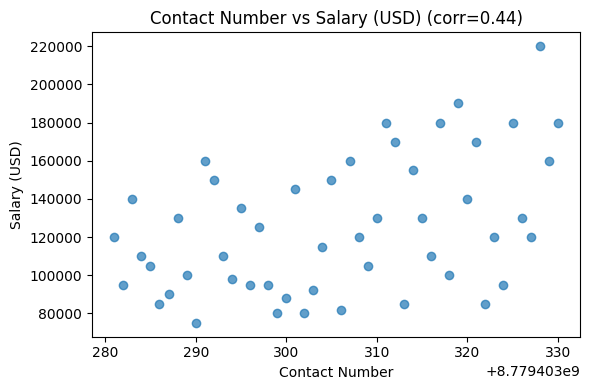

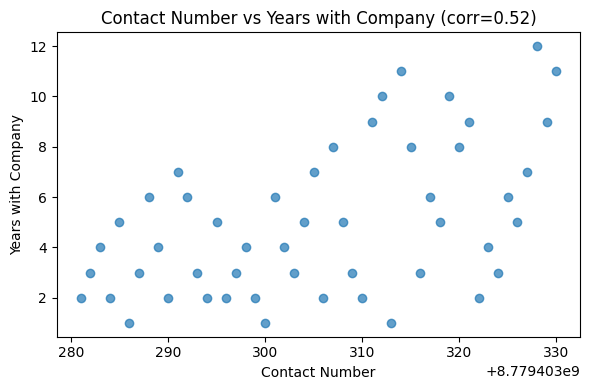

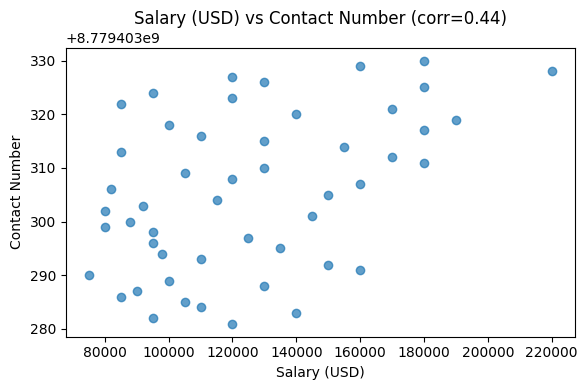

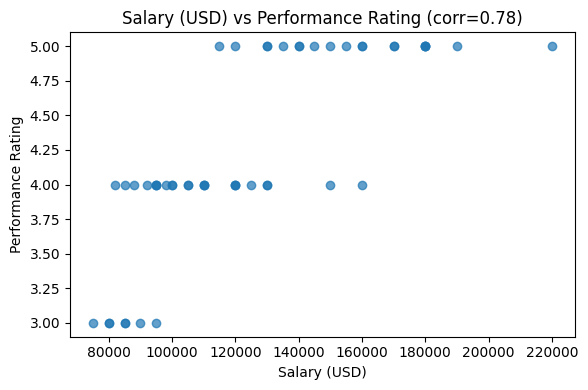

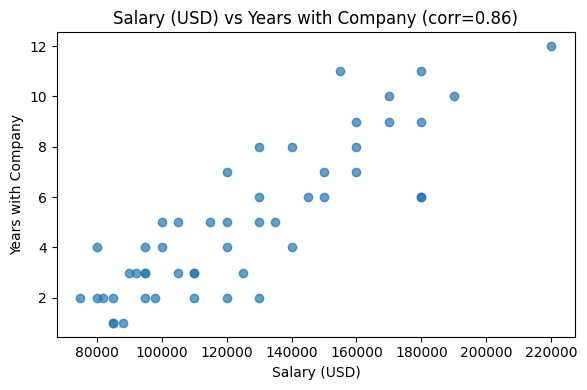

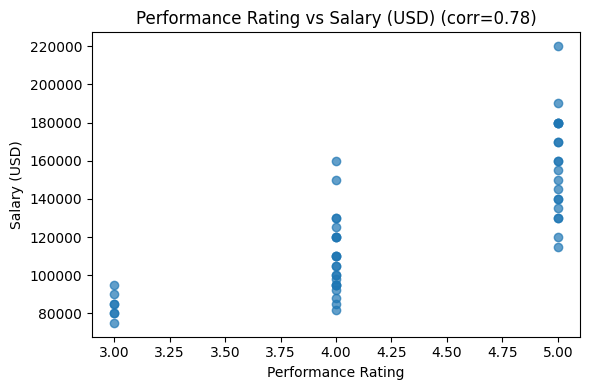

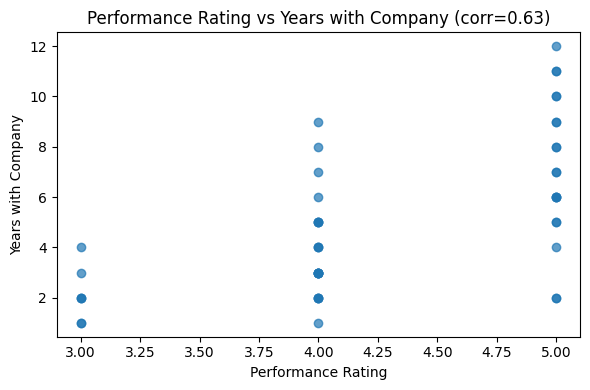

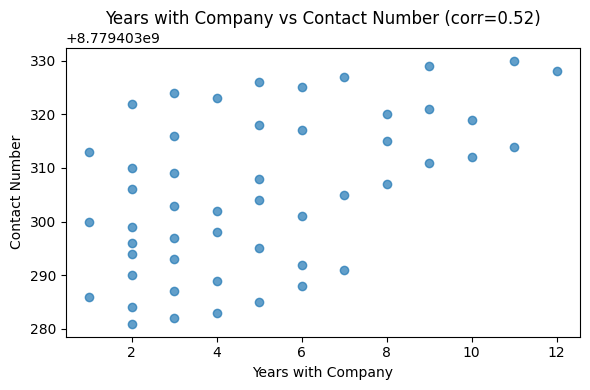

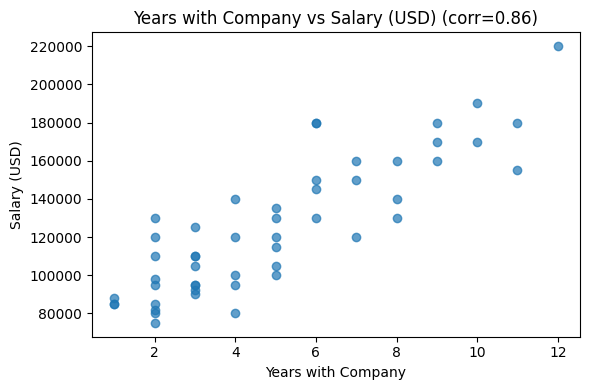

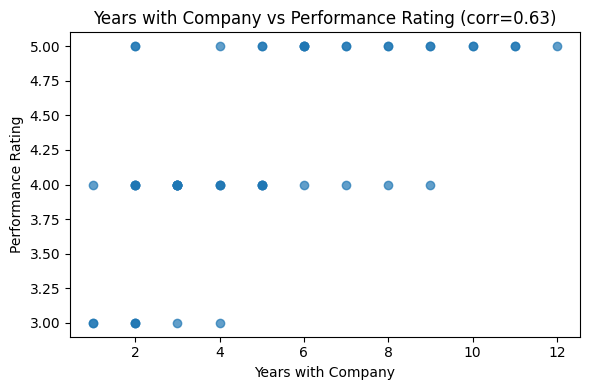

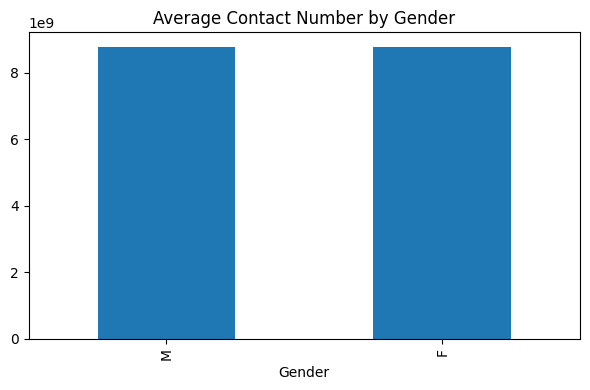

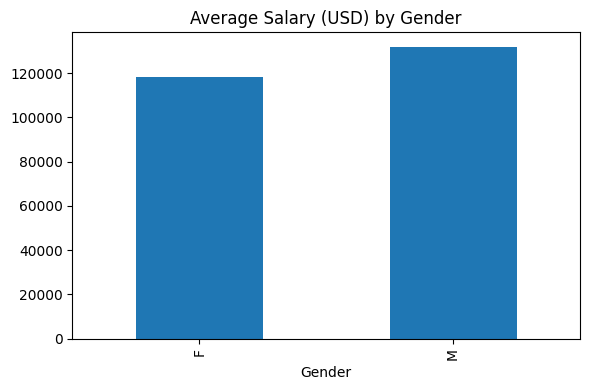

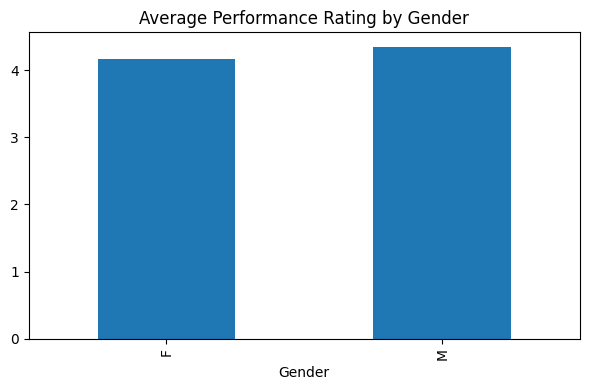

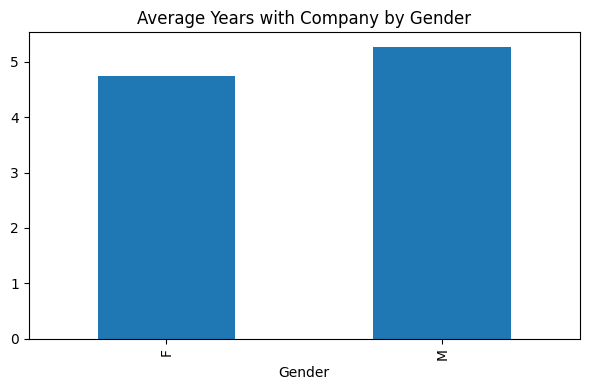

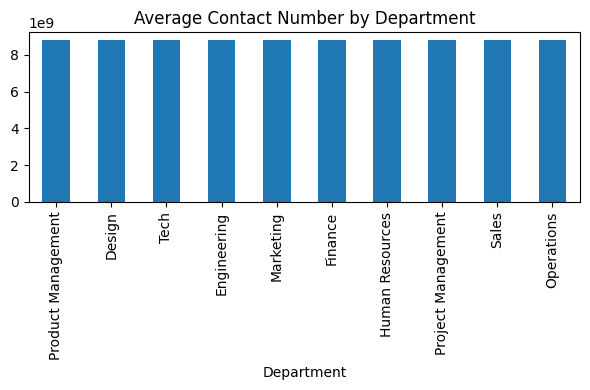

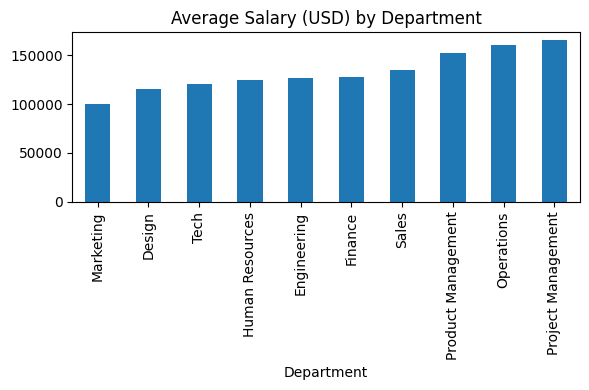

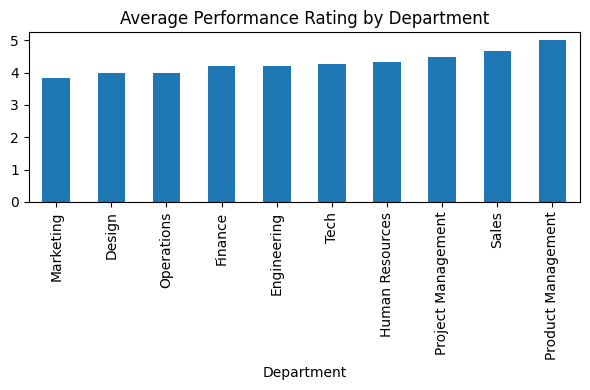

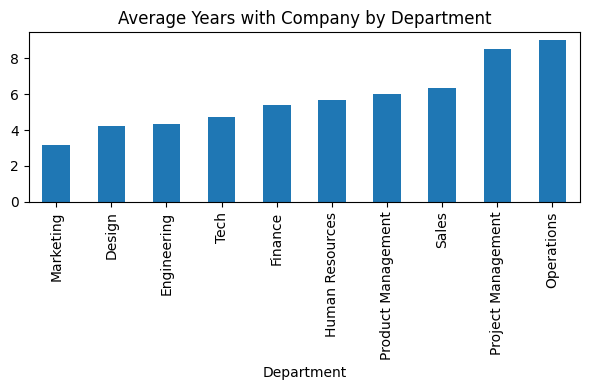

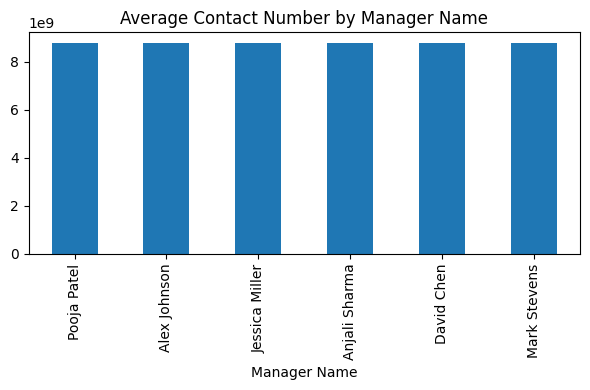

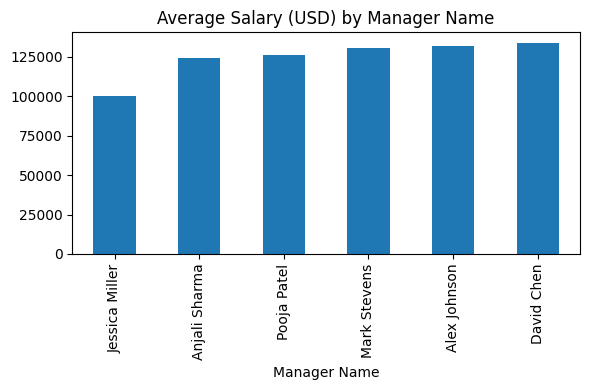

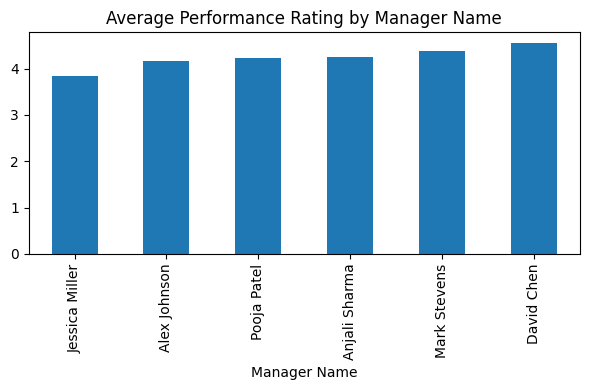

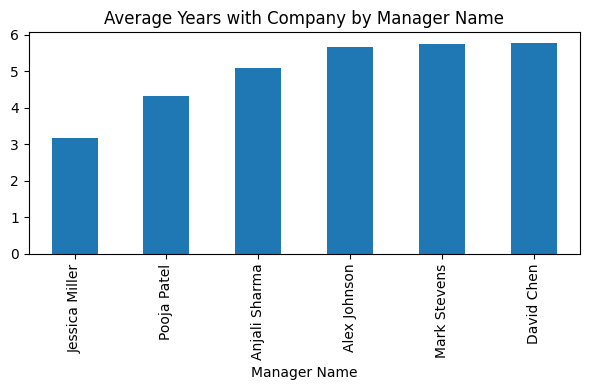

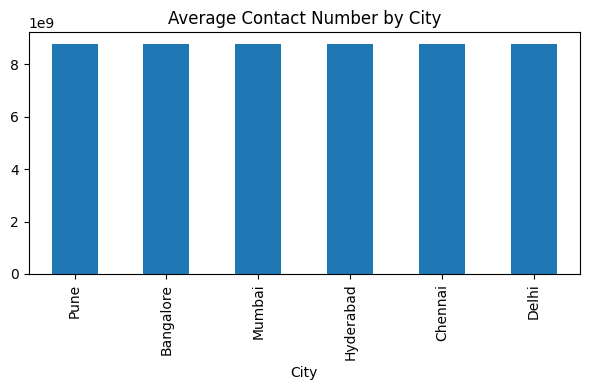

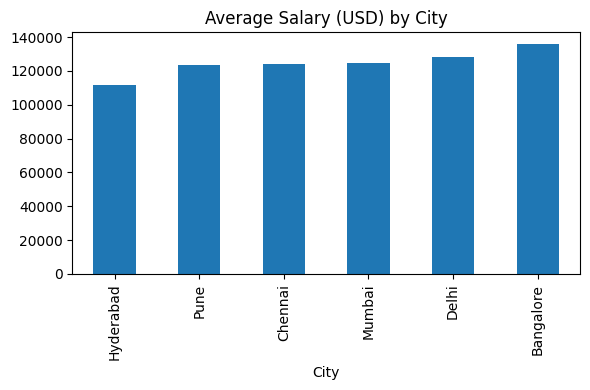

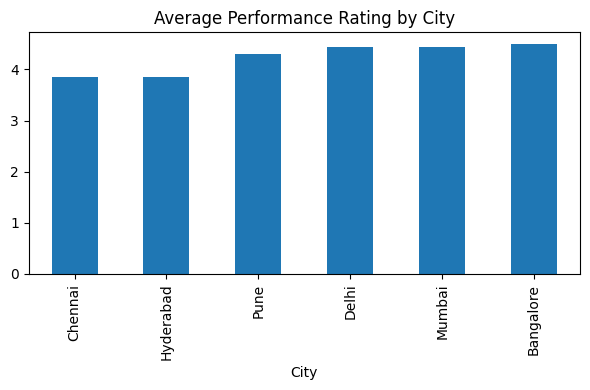

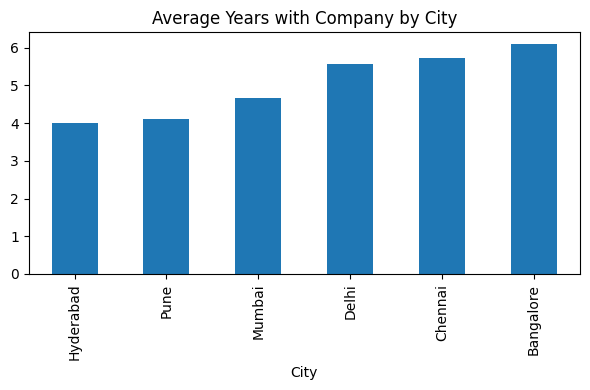


✅ Smart Auto-Plot finished.
Plotted pairs: [('Contact Number', 'Salary (USD)'), ('Contact Number', 'Years with Company'), ('Salary (USD)', 'Contact Number'), ('Salary (USD)', 'Performance Rating'), ('Salary (USD)', 'Years with Company'), ('Performance Rating', 'Salary (USD)'), ('Performance Rating', 'Years with Company'), ('Years with Company', 'Contact Number'), ('Years with Company', 'Salary (USD)'), ('Years with Company', 'Performance Rating'), ('Gender', 'Contact Number'), ('Gender', 'Salary (USD)'), ('Gender', 'Performance Rating'), ('Gender', 'Years with Company'), ('Department', 'Contact Number'), ('Department', 'Salary (USD)'), ('Department', 'Performance Rating'), ('Department', 'Years with Company'), ('Manager Name', 'Contact Number'), ('Manager Name', 'Salary (USD)'), ('Manager Name', 'Performance Rating'), ('Manager Name', 'Years with Company'), ('City', 'Contact Number'), ('City', 'Salary (USD)'), ('City', 'Performance Rating'), ('City', 'Years with Company')]

🧠 LLM Expl

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
import re

# ---------------------------------------
# 1️⃣ Detect Column Types Safely (Fixed)
# ---------------------------------------
def detect_column_types(df):
    numeric_cols = []
    categorical_cols = []
    date_cols = []

    for col in df.columns:
        # Skip anything that looks like an ID
        if re.search(r'\b(id|_id|ID|Id)\b', col, re.IGNORECASE):
            continue

        col_lower = col.lower()

        # ✅ Detect date-like columns by name pattern (not by brute force)
        if any(keyword in col_lower for keyword in ["date", "dob", "time"]):
            date_cols.append(col)
            continue

        # ✅ Classify as numeric or categorical based on dtype
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
        else:
            # Try to see if it's convertible to numeric
            try:
                df[col].astype(float)
                numeric_cols.append(col)
            except:
                categorical_cols.append(col)

    print("📊 Numeric columns:", numeric_cols)
    print("🗂️ Categorical columns:", categorical_cols)
    print("⏱️ Date columns:", date_cols)
    return numeric_cols, categorical_cols, date_cols


# ---------------------------------------
# 2️⃣ Smart Auto Plotter (No LLM Touching)
# ---------------------------------------
def smart_auto_plot(df):
    numeric_cols, categorical_cols, date_cols = detect_column_types(df)
    plotted_pairs = []

    if len(numeric_cols) == 0:
        print("\n⚠️ No numeric columns detected. Skipping numeric-based plots.")
        return plotted_pairs

    # Correlation threshold for scatter plots
    corr_matrix = df[numeric_cols].corr(method='pearson')

    for col1 in numeric_cols:
        for col2 in numeric_cols:
            if col1 != col2:
                corr = corr_matrix.loc[col1, col2]
                if abs(corr) > 0.4:
                    plt.figure(figsize=(6, 4))
                    plt.scatter(df[col1], df[col2], alpha=0.7)
                    plt.title(f"{col1} vs {col2} (corr={corr:.2f})")
                    plt.xlabel(col1)
                    plt.ylabel(col2)
                    plt.tight_layout()
                    plt.show()
                    plotted_pairs.append((col1, col2))

    # Bar charts for categorical vs numeric
    for cat in categorical_cols:
        if df[cat].nunique() > 10:
            continue
        for num in numeric_cols:
            plt.figure(figsize=(6, 4))
            df.groupby(cat)[num].mean().sort_values().plot(kind="bar")
            plt.title(f"Average {num} by {cat}")
            plt.tight_layout()
            plt.show()
            plotted_pairs.append((cat, num))

    print("\n✅ Smart Auto-Plot finished.")
    print("Plotted pairs:", plotted_pairs)
    return plotted_pairs


# ---------------------------------------
# 3️⃣ Send Explanation to LLM
# ---------------------------------------
def explain_with_llm(df, plotted_pairs):
    try:
        summary = {
            "num_cols": df.select_dtypes(include=[np.number]).columns.tolist(),
            "cat_cols": df.select_dtypes(exclude=[np.number]).columns.tolist(),
            "sample_data": df.head(3).to_dict(orient="records"),
            "plots": plotted_pairs
        }

        prompt = f"""
        You are a data analyst. Given this dataset summary and the plots that were generated, 
        explain the possible trends or relationships observed in a human-like, concise way.

        Dataset summary:
        {json.dumps(summary, indent=2)}

        Return just a plain text paragraph (no JSON or markdown).
        """

        response = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": "qwen2.5:1.5b",
                "prompt": prompt,
                "stream": False
            },
            timeout=60
        )

        llm_text = response.json().get("response", "").strip()
        print("\n🧠 LLM Explanation:")
        print(llm_text)

    except Exception as e:
        print("\n❌ Error while calling LLM for explanation:", e)


# ---------------------------------------
# 4️⃣ Main Execution
# ---------------------------------------
if __name__ == "__main__":
    plotted_pairs = smart_auto_plot(df)
    explain_with_llm(df, plotted_pairs)
